[5, 0, 0, 2, 2] 4900 615.0
Mejor combinación: [5, 0, 0, 2, 2]
Capital usado: 4900
Rendimiento: 615.0


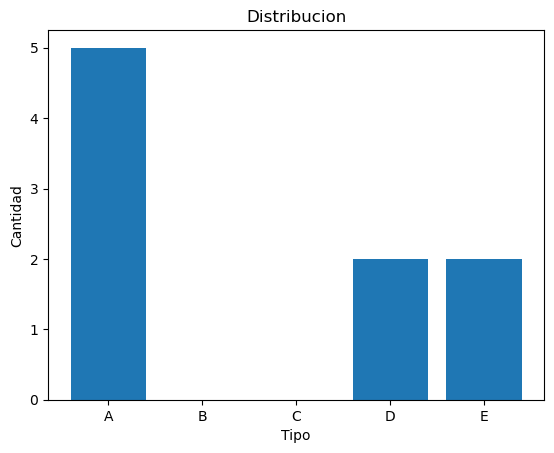

In [10]:
from random import random, randint, sample
from collections import namedtuple
import matplotlib.pyplot as plt

# Calcula el capital invertido por un individuo
def capitalInvertido(individuo):
    return sum(map(lambda x,y: x*y.precio, individuo, inversiones))

# Calcula el rendimiento obtenido por un individuo
def rendimiento(individuo):
    return sum(map(lambda x,y: x*y.precio*y.rendim, individuo, inversiones))


# Si un individuo gasta más capital del disponible, se eliminan aleatoriamente inversiones hasta que se ajusta al capital
def ajustaCapital(individuo):
    ajustado = individuo[:]
    while capitalInvertido(ajustado)>capital:
        pos = randint(0,len(ajustado)-1)
        if ajustado[pos] > 0:
            ajustado[pos] -= 1
    return ajustado

# Crea un individuo al azar, en este caso una selección de inversiones que no excedan el capital disponible
def creaIndividuo(inversiones, capital):
    individuo = [0]*len(inversiones)
    while capitalInvertido(individuo) < capital:
        eleccion = randint(0,len(inversiones)-1)
        individuo[eleccion] += 1
    return ajustaCapital(individuo)


# Crea un nuevo individuo cruzando otros dos (cuyas posiciones se indican en el segundo parámetro)
def cruza(poblacion, posiciones):
    L = len(poblacion[0])
    # Toma los genes del primer progenitor y luego toma al azar un segmento de entre 1 y L genes del segundo progenitor
    hijo = poblacion[posiciones[0]][:]
    inicio = randint(0,L-1)
    fin = randint(inicio+1,L)
    hijo[inicio:fin] = poblacion[posiciones[1]][inicio:fin]
    return ajustaCapital(hijo)


# Aplica mutaciones a un individuo según una tasa dada; garantiza que cumple las restricciones de capital e inversiones
def muta(individuo, tasaMutacion):
    mutado = []
    for i in range(len(individuo)):
        if random() > tasaMutacion:
            mutado.append(individuo[i])
        else:
            mutado.append(randint(0,inversiones[i].cantidad))
    return ajustaCapital(mutado)


# Hace evolucionar el sistema durante un número de generaciones
def evoluciona(poblacion, generaciones):
    # Ordena la población inicial por rendimiento producido
    poblacion.sort(key=lambda x:rendimiento(x))
    # Algunos valores útiles
    N = len(poblacion)
    tasaMutacion = 0.01
    # Genera una lista del tipo [0,1,1,2,2,2,3,3,3,3,...] para representar las probabilidades de reproducirse de cada individuo (el primero 1 posibilidad, el segundo 2, etc.)
    reproduccion = [x for x in range(N) for y in range(x+1)]
    for i in range(generaciones):
        # Se generan N-1 nuevos individuos cruzando los existentes (sin que se repitan los padres)
        padres = sample(reproduccion,2)
        while padres[0]==padres[1]:
            padres = sample(reproduccion,2)
        hijos = [cruza(poblacion,padres) for x in range(N-1)]
        # Se aplican mutaciones con una cierta probabilidad
        hijos = [muta(x, tasaMutacion) for x in hijos]
        # Se añade el mejor individuo de la población anterior (elitismo)
        hijos.append(poblacion[-1])
        poblacion = hijos
        # Se ordenan los individuos por rendimiento
        poblacion.sort(key=lambda x:rendimiento(x))
    # Devuelve el mejor individuo encontrado
    return poblacion[-1]


# Declara una tupla con nombres para representar cada inversión
Inversion = namedtuple('Inversion', 'precio cantidad rendim')

# Genera una lista de tuplas Inversion
inversiones = [
    Inversion(500, 5, 0.15),   # A
    Inversion(700, 6, 0.05),   # B
    Inversion(300, 10, 0.03),  # C
    Inversion(800, 3, 0.10),   # D 
    Inversion(400, 7, 0.10)    # E
]

capital     = 5000
individuos  = 20
generaciones = 100

poblacion = [creaIndividuo(inversiones,capital) for _ in range(individuos)]

# Nota: para simplificar el programa se accede a inversiones y capital de forma global (sólo se leen, no se modifican)
mejor = evoluciona(poblacion, generaciones)
print(mejor, capitalInvertido(mejor), rendimiento(mejor))

print("Mejor combinación:", mejor)
print("Capital usado:", capitalInvertido(mejor))
print("Rendimiento:", rendimiento(mejor))

labels = ["A", "B", "C", "D", "E"]

plt.figure()
plt.bar(labels, mejor)
plt.xlabel("Tipo")
plt.ylabel("Cantidad")
plt.title("Distribucion")
plt.show()

# Ahora con la libreria Deep:

[4, 0, 0, 2, 3] 4800 580.0
Mejor combinación: [4, 0, 0, 2, 3]
Capital usado: 4800
Rendimiento: 580.0


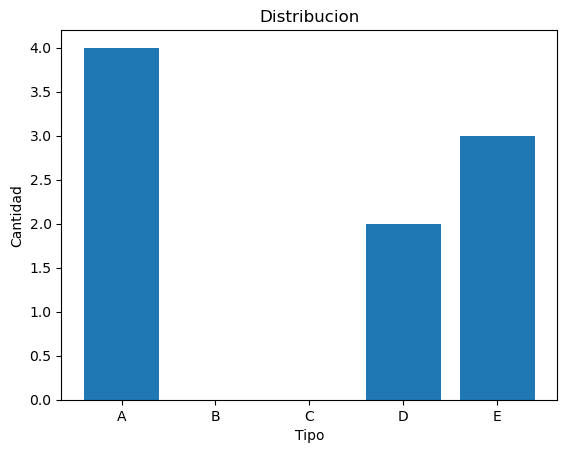

In [11]:
from deap import base, creator, tools, algorithms
import random
import matplotlib.pyplot as plt

Inversion = namedtuple('Inversion', 'precio cantidad rendim')

inversiones = [
    Inversion(500, 5, 0.15),   # A
    Inversion(700, 6, 0.05),   # B
    Inversion(300, 10, 0.03),  # C
    Inversion(800, 3, 0.10),   # D
    Inversion(400, 7, 0.10)    # E
]

capital      = 5000
individuos   = 20
generaciones = 100

def capitalInvertido(individuo):
    return sum(x * y.precio for x, y in zip(individuo, inversiones))

def rendimiento(individuo):
    return sum(x * y.precio * y.rendim for x, y in zip(individuo, inversiones))

def ajustaCapital(individuo):
    """Si se excede el capital, reduce unidades al azar hasta ajustar."""
    while capitalInvertido(individuo) > capital:
        pos = randint(0, len(individuo) - 1)
        if individuo[pos] > 0:
            individuo[pos] -= 1
    return individuo

# Usando DEAP
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)
toolbox = base.Toolbox()

def gen_aleatorio(inversion):
    return randint(0, inversion.cantidad)

def crear_individuo():
    ind = creator.Individual([0] * len(inversiones))
    while capitalInvertido(ind) < capital:
        eleccion = randint(0, len(inversiones) - 1)
        ind[eleccion] += 1
    ajustaCapital(ind)
    return ind

toolbox.register("individual", crear_individuo)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def evaluar(individuo):
    return (rendimiento(individuo),)

toolbox.register("evaluate", evaluar)

def cruce_segmento(ind1, ind2):
    L = len(ind1)
    inicio = randint(0, L - 1)
    fin    = randint(inicio + 1, L)
    hijo = creator.Individual(ind1[:])
    hijo[inicio:fin] = ind2[inicio:fin]
    ajustaCapital(hijo)
    ind1[:] = hijo        
    return ind1, ind2       

toolbox.register("mate", cruce_segmento)

def mutacion(individuo, tasa):
    for i in range(len(individuo)):
        if __import__('random').random() <= tasa:
            individuo[i] = randint(0, inversiones[i].cantidad)
    ajustaCapital(individuo)
    return (individuo,)

toolbox.register("mutate", mutacion, tasa=0.01)
toolbox.register("select", tools.selTournament, tournsize=3)

poblacion = toolbox.population(n=individuos)

for ind in poblacion:
    ind.fitness.values = toolbox.evaluate(ind)

for gen in range(generaciones):
    descendencia = toolbox.select(poblacion, len(poblacion) - 1)
    descendencia = list(map(toolbox.clone, descendencia))

    for hijo1, hijo2 in zip(descendencia[::2], descendencia[1::2]):
        toolbox.mate(hijo1, hijo2)
        del hijo1.fitness.values
        del hijo2.fitness.values
        
    for mutante in descendencia:
        toolbox.mutate(mutante)
        del mutante.fitness.values

    invalidos = [ind for ind in descendencia if not ind.fitness.valid]
    for ind in invalidos:
        ind.fitness.values = toolbox.evaluate(ind)

    mejor_anterior = tools.selBest(poblacion, 1)[0]
    descendencia.append(toolbox.clone(mejor_anterior))

    poblacion = descendencia

mejor = tools.selBest(poblacion, 1)[0]

print(list(mejor), capitalInvertido(mejor), rendimiento(mejor))
print("Mejor combinación:", list(mejor))
print("Capital usado:", capitalInvertido(mejor))
print("Rendimiento:", rendimiento(mejor))

labels = ["A", "B", "C", "D", "E"]

plt.figure()
plt.bar(labels, mejor)
plt.xlabel("Tipo")
plt.ylabel("Cantidad")
plt.title("Distribucion")
plt.show()

# Comparacion:
Diferencias en la programación de la función objetivo
- Original: La función objetivo es rendimiento(), una función de Python que suma cantidad × precio × rendimiento para cada inversión. Se llama como clave de ordenación: poblacion.sort(key=lambda x: rendimiento(x)).
- DEAP: La función objetivo se registra en el toolbox como toolbox.register("evaluate", evaluar) y debe devolver una tupla, ya que DEAP soporta optimización multiobjetivo y es su formato estándar.

Diferencias en la programación del fitness
- Original: No existe un objeto de fitness explícito. El fitness es implícito, los individuos se ordenan por rendimiento() y el mejor queda al final de la lista.
- DEAP: Se define una clase de fitness con creator.create("FitnessMax", base.Fitness, weights=(1.0,)) y se asocia a cada individuo con creator.create("Individual", list, fitness=creator.FitnessMax). Cada individuo carga su propio valor de fitness en ind.fitness.values, y DEAP lo gestiona internamente.

Diferencias en la codificación de los operadores de selección, cruza y mutación
- Original: Los tres operadores son funciones Python sueltas (cruza, muta, lista reproduccion para selección) invocadas manualmente dentro del bucle evoluciona().
- DEAP: Los tres operadores se registran en el toolbox: toolbox.register("select", tools.selTournament, tournsize=3), toolbox.register("mate", cruce_segmento), toolbox.register("mutate", mutacion, tasa=0.01) 